In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

root = Path.cwd()
if not (root / 'network.py').exists():
    root = root.parent
example_dir = root / 'syn_swell'
if str(root) not in sys.path:
    sys.path.append(str(root))

from network import NoiseNetwork, set_seed

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'seismic'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(torch.cuda.get_device_name(device))
else:
    print('Using CPU')

NVIDIA RTX 4000 SFF Ada Generation


In [2]:
def snr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    num = np.sum(y_true ** 2)
    den = np.sum((y_true - y_pred) ** 2) + 1e-12
    return 10.0 * np.log10(num / den)


def clip_abs(x, q=99.0):
    return float(np.percentile(np.abs(x), q))


def show_section(ax, x, title, cmap='gray'):
    v = 1
    im = ax.imshow(x, aspect='auto', cmap=cmap, vmin=-v, vmax=v)
    ax.set_title(title)
    ax.set_xlabel('Trace')
    ax.set_ylabel('Time sample')
    return im

d shape: (480, 992)
dn shape: (480, 992)
Input noisy SNR: 7.811616957761895


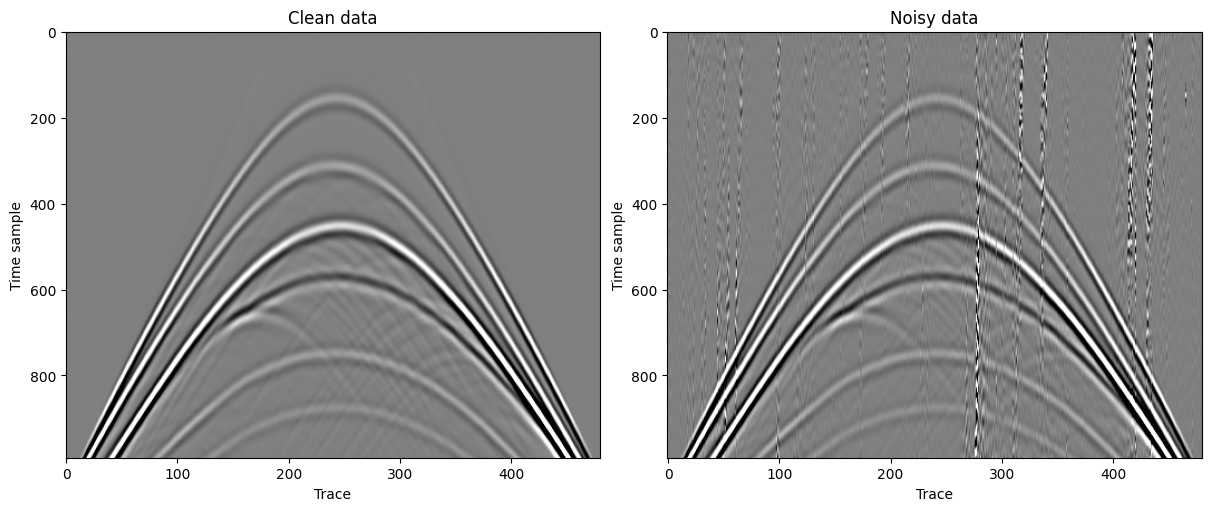

In [3]:
mat = loadmat(example_dir / 'data_2.mat')
d = np.asarray(mat['d'], dtype=np.float64).T
dn = np.asarray(mat['dn'], dtype=np.float64).T
print('d shape:', d.shape)
print('dn shape:', dn.shape)
print('Input noisy SNR:', snr(d, dn))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
show_section(axes[0], d.T, 'Clean data')
show_section(axes[1], dn.T, 'Noisy data')
plt.show()

In [4]:
def b3(sigma):
    return np.array([
        (1.0 - sigma) * (2.0 - sigma) / 12.0,
        (2.0 + sigma) * (2.0 - sigma) / 6.0,
        (1.0 + sigma) * (2.0 + sigma) / 12.0,
    ], dtype=np.float64)


def b3d(sigma):
    return np.array([
        -((2.0 - sigma) + (1.0 - sigma)) / 12.0,
        ((2.0 - sigma) - (2.0 + sigma)) / 6.0,
        ((2.0 + sigma) + (1.0 + sigma)) / 12.0,
    ], dtype=np.float64)


def b5(sigma):
    return np.array([
        (1.0 - sigma) * (2.0 - sigma) * (3.0 - sigma) * (4.0 - sigma) / 1680.0,
        (4.0 - sigma) * (2.0 - sigma) * (3.0 - sigma) * (4.0 + sigma) / 420.0,
        (4.0 - sigma) * (3.0 - sigma) * (3.0 + sigma) * (4.0 + sigma) / 280.0,
        (4.0 - sigma) * (2.0 + sigma) * (3.0 + sigma) * (4.0 + sigma) / 420.0,
        (1.0 + sigma) * (2.0 + sigma) * (3.0 + sigma) * (4.0 + sigma) / 1680.0,
    ], dtype=np.float64)


def b5d(sigma):
    return np.array([
        -(2.0 - sigma) * (3.0 - sigma) * (4.0 - sigma) / 1680.0
        - (1.0 - sigma) * (3.0 - sigma) * (4.0 - sigma) / 1680.0
        - (1.0 - sigma) * (2.0 - sigma) * (4.0 - sigma) / 1680.0
        - (1.0 - sigma) * (2.0 - sigma) * (3.0 - sigma) / 1680.0,
        -(2.0 - sigma) * (3.0 - sigma) * (4.0 + sigma) / 420.0
        - (4.0 - sigma) * (3.0 - sigma) * (4.0 + sigma) / 420.0
        - (4.0 - sigma) * (2.0 - sigma) * (4.0 + sigma) / 420.0
        + (4.0 - sigma) * (2.0 - sigma) * (3.0 - sigma) / 420.0,
        -(3.0 - sigma) * (3.0 + sigma) * (4.0 + sigma) / 280.0
        - (4.0 - sigma) * (3.0 + sigma) * (4.0 + sigma) / 280.0
        + (4.0 - sigma) * (3.0 - sigma) * (4.0 + sigma) / 280.0
        + (4.0 - sigma) * (3.0 - sigma) * (3.0 + sigma) / 280.0,
        -(2.0 + sigma) * (3.0 + sigma) * (4.0 + sigma) / 420.0
        + (4.0 - sigma) * (3.0 + sigma) * (4.0 + sigma) / 420.0
        + (4.0 - sigma) * (2.0 + sigma) * (4.0 + sigma) / 420.0
        + (4.0 - sigma) * (2.0 + sigma) * (3.0 + sigma) / 420.0,
        (2.0 + sigma) * (3.0 + sigma) * (4.0 + sigma) / 1680.0
        + (1.0 + sigma) * (3.0 + sigma) * (4.0 + sigma) / 1680.0
        + (1.0 + sigma) * (2.0 + sigma) * (4.0 + sigma) / 1680.0
        + (1.0 + sigma) * (2.0 + sigma) * (3.0 + sigma) / 1680.0,
    ], dtype=np.float64)


def conv_allpass(data, dip, order=2):
    n1, n2 = data.shape
    nw = 1 if order == 1 else 2
    u1 = np.zeros_like(data, dtype=np.float64)
    u2 = np.zeros_like(data, dtype=np.float64)

    filt = (b3, b3d) if order == 1 else (b5, b5d)

    for i1 in range(nw, n1 - nw):
        for i2 in range(n2 - 1):
            sigma = float(np.clip(dip[i1, i2], -3.0, 3.0))
            fv = filt[0](sigma)
            fd = filt[1](sigma)
            for k, iw in enumerate(range(-nw, nw + 1)):
                diff = data[i1 + iw, i2 + 1] - data[i1 - iw, i2]
                u1[i1, i2] += diff * fd[k]
                u2[i1, i2] += diff * fv[k]
    return u1, u2


def smooth_ratio(num, den, smooth_sigma=(4.0, 4.0), eps=1e-3):
    ratio = num / (den + eps * np.sign(den) + 1e-12)
    ratio = np.nan_to_num(ratio, nan=0.0, posinf=0.0, neginf=0.0)
    return gaussian_filter(ratio, sigma=smooth_sigma, mode='nearest')


def estimate_pwd_dip(data, niter=6, order=2, smooth_sigma=(5.0, 5.0), eps=1e-3):
    dip = np.zeros_like(data, dtype=np.float64)
    history = []
    for _ in range(niter):
        u1, u2 = conv_allpass(data, dip, order=order)
        update = smooth_ratio(-u2, u1, smooth_sigma=smooth_sigma, eps=eps)
        dip += update
        dip = np.clip(dip, -3.0, 3.0)
        history.append(float(np.linalg.norm(update) / (np.linalg.norm(dip) + 1e-12)))
    return dip, history


In [5]:
def dip_aligned_tv_second_order(x, dip_field):
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))

    tx = torch.ones_like(dip_field)
    ty = dip_field
    norm = torch.sqrt(tx * tx + ty * ty + 1e-12)
    tx = tx / norm
    ty = ty / norm

    first_directional = tx * dx + ty * dy

    dfx = first_directional[:, :, :, 1:] - first_directional[:, :, :, :-1]
    dfy = first_directional[:, :, 1:, :] - first_directional[:, :, :-1, :]
    dfx = F.pad(dfx, (0, 1, 0, 0))
    dfy = F.pad(dfy, (0, 0, 0, 1))

    second_directional = tx * dfx + ty * dfy
    return second_directional.abs().mean()


def make_dip_tensor(dip_np):
    return torch.from_numpy(dip_np).unsqueeze(0).unsqueeze(0).float().to(device)


def tv_weight_schedule(epoch, warmup=50, ramp=150, max_weight=0.2):
    if epoch < warmup:
        return 0.0
    alpha = min(1.0, (epoch - warmup) / max(ramp, 1))
    return max_weight * alpha


In [6]:
def train_adaptive_dip2(noisy_np, clean_np, epochs=300, lr=1e-3, seed=42, update_every=50, warmup=50, ramp=150, max_tv_weight=0.2, pwd_niter=6, pwd_order=2):
    set_seed(seed)
    network = NoiseNetwork(1, 1, blindspot=True).to(device)
    optimizer = optim.Adam(network.parameters(), lr=lr)
    noisy_tensor = torch.from_numpy(noisy_np).unsqueeze(0).unsqueeze(0).float().to(device)

    history = {'loss': [], 'data_loss': [], 'reg_loss': [], 'snr': [], 'tv_weight': [], 'dip_updates': []}
    best_snr = -np.inf
    best_pred = None
    dip_tensor = None
    latest_dip = None

    for epoch in tqdm(range(epochs), desc='Adaptive dip2 TV'):
        current_tv_weight = tv_weight_schedule(epoch, warmup=warmup, ramp=ramp, max_weight=max_tv_weight)

        if epoch >= warmup and epoch % update_every == 0:
            with torch.no_grad():
                current_pred = network(noisy_tensor).detach().cpu().numpy().squeeze()
            latest_dip, _ = estimate_pwd_dip(current_pred, niter=pwd_niter, order=pwd_order, smooth_sigma=(5.0, 5.0), eps=1e-3)
            dip_tensor = make_dip_tensor(latest_dip)
            history['dip_updates'].append((int(epoch), float(np.mean(np.abs(latest_dip)))))

        optimizer.zero_grad()
        prediction = network(noisy_tensor)
        data_loss = F.l1_loss(prediction, noisy_tensor)

        if dip_tensor is None or current_tv_weight == 0.0:
            reg_loss = torch.zeros((), device=device, dtype=prediction.dtype)
        else:
            reg_loss = dip_aligned_tv_second_order(prediction, dip_tensor)

        total_loss = data_loss + current_tv_weight * reg_loss
        total_loss.backward()
        optimizer.step()

        pred_np = prediction.detach().cpu().numpy().squeeze()
        current_snr = snr(clean_np, pred_np)
        history['loss'].append(float(total_loss.item()))
        history['data_loss'].append(float(data_loss.item()))
        history['reg_loss'].append(float(reg_loss.item()))
        history['snr'].append(float(current_snr))
        history['tv_weight'].append(float(current_tv_weight))

        if current_snr > best_snr:
            best_snr = current_snr
            best_pred = pred_np.copy()

    return best_pred, history, latest_dip


In [7]:
epochs = 400
lr = 1e-3
update_every = 50
warmup = 50
ramp = 300
max_tv_weight = 4
pwd_niter = 6
pwd_order = 2

print(f'epochs={epochs}, lr={lr}, update_every={update_every}, warmup={warmup}, ramp={ramp}, max_tv_weight={max_tv_weight}, pwd_order={pwd_order}')


epochs=400, lr=0.001, update_every=50, warmup=50, ramp=300, max_tv_weight=4, pwd_order=2


In [8]:
pred_adaptive, hist_adaptive, final_dip = train_adaptive_dip2(
    noisy_np=dn,
    clean_np=d,
    epochs=epochs,
    lr=lr,
    seed=42,
    update_every=update_every,
    warmup=warmup,
    ramp=ramp,
    max_tv_weight=max_tv_weight,
    pwd_niter=pwd_niter,
    pwd_order=pwd_order,
)

print('Input noisy SNR:', snr(d, dn))
print('Best adaptive dip2 TV SNR:', np.max(hist_adaptive['snr']))
print('Final adaptive dip2 TV SNR:', snr(d, pred_adaptive))


Adaptive dip2 TV:   0%|          | 0/400 [00:00<?, ?it/s]

Input noisy SNR: 7.811616957761895
Best adaptive dip2 TV SNR: 21.42898066784156
Final adaptive dip2 TV SNR: 21.42898066784156


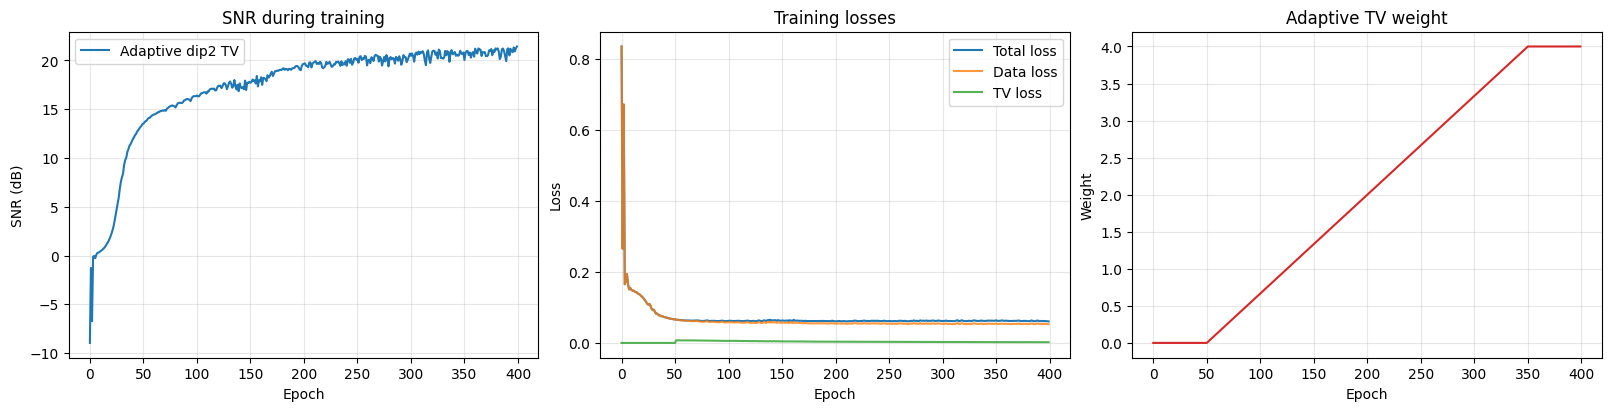

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

axes[0].plot(hist_adaptive['snr'], label='Adaptive dip2 TV')
axes[0].set_title('SNR during training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('SNR (dB)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist_adaptive['loss'], label='Total loss')
axes[1].plot(hist_adaptive['data_loss'], label='Data loss', alpha=0.8)
axes[1].plot(hist_adaptive['reg_loss'], label='TV loss', alpha=0.8)
axes[1].set_title('Training losses')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(hist_adaptive['tv_weight'], color='tab:red')
axes[2].set_title('Adaptive TV weight')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Weight')
axes[2].grid(True, alpha=0.3)

plt.show()


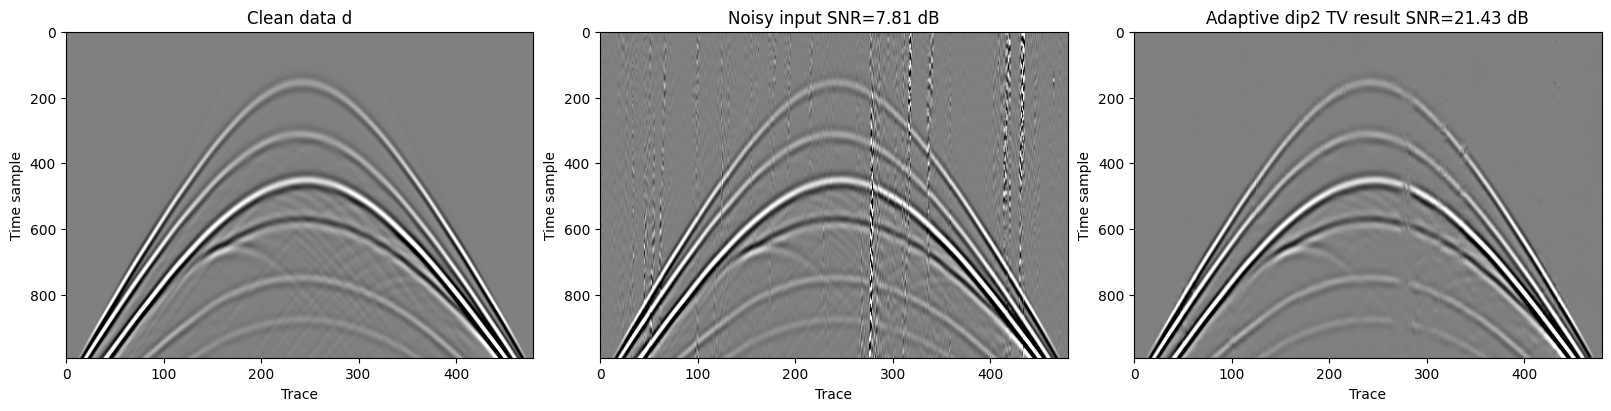

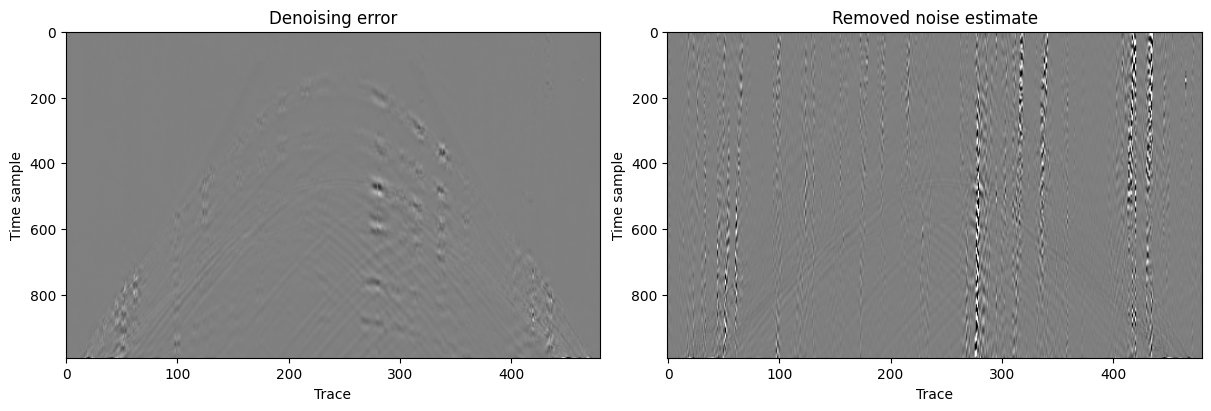

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
show_section(axes[0], d.T, 'Clean data d')
show_section(axes[1], dn.T, f'Noisy input SNR={snr(d, dn):.2f} dB')
show_section(axes[2], pred_adaptive.T, f'Adaptive dip2 TV result SNR={snr(d, pred_adaptive):.2f} dB')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
show_section(axes[0], pred_adaptive.T - d.T, 'Denoising error')
show_section(axes[1], dn.T - pred_adaptive.T, 'Removed noise estimate')
plt.show()


In [11]:
from scipy.io import savemat
output_dir = example_dir / 'outputs'
output_dir.mkdir(exist_ok=True)
savemat(output_dir / 'curved_denoised.mat', {'dr': pred_adaptive.T, 'snr': hist_adaptive['snr']})
